## Import Modules

In [95]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score , accuracy_score, confusion_matrix,recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


## Import Datasets

In [19]:
df= pd.read_csv("loan_approval_data.csv")

In [20]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [22]:
print("Null Values In Each Columns")
df.isnull().sum()

Null Values In Each Columns


Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [23]:
print(f"Duplicated Values Are :{df.duplicated().sum()}")

Duplicated Values Are :0


## Cleaning Data

#### Handle Missing Values

In [24]:
categorical_cols= df.select_dtypes(include=["object"]).columns
numerical_cols= df.select_dtypes(include=["number"]).columns

In [25]:
# Handle Missing Values In Numerical Cols
num_imp = SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [26]:
# Handle Missing Values In Categorical Cols

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols]= cat_imp.fit_transform(df[categorical_cols])

In [27]:
print(f"All Null Values Are Replaced")
df.isna().sum()

All Null Values Are Replaced


Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

## EDA

Text(0.5, 1.0, 'Is Loan Approved Yes / No')

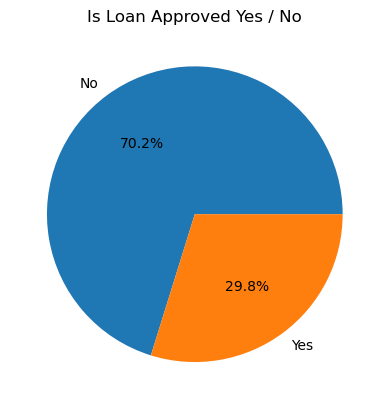

In [28]:
# How Balanced Our Classes Are

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Is Loan Approved Yes / No")

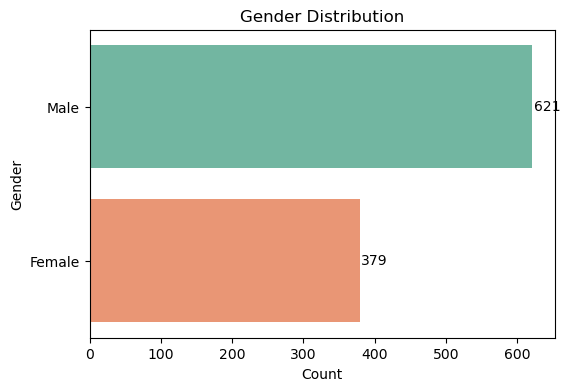

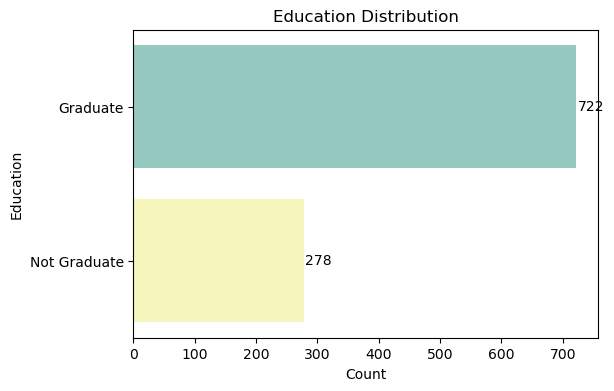

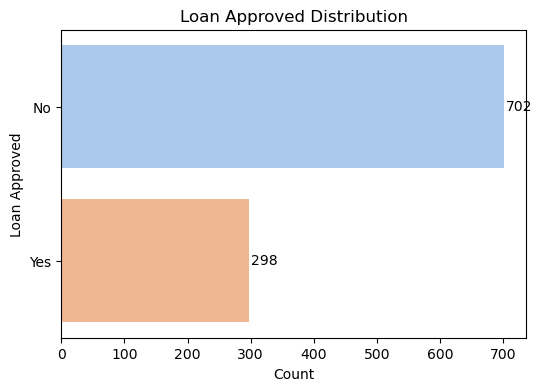

In [29]:
counts = df["Gender"].value_counts()

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=counts.values,
    y=counts.index,
    hue=counts.index,
    palette="Set2",
    legend=False
)

for i, value in enumerate(counts.values):
    ax.text(value + 2, i, str(value), va="center")

plt.title("Gender Distribution")
plt.xlabel("Count")
plt.ylabel("Gender")
plt.show()


# ---------------- Education ----------------
counts = df["Education_Level"].value_counts()

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=counts.values,
    y=counts.index,
    hue=counts.index,
    palette="Set3",
    legend=False
)

for i, value in enumerate(counts.values):
    ax.text(value + 2, i, str(value), va="center")

plt.title("Education Distribution")
plt.xlabel("Count")
plt.ylabel("Education")
plt.show()


# ---------------- Loan Approved ----------------
counts = df["Loan_Approved"].value_counts()

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=counts.values,
    y=counts.index,
    hue=counts.index,
    palette="pastel",
    legend=False
)

for i, value in enumerate(counts.values):
    ax.text(value + 2, i, str(value), va="center")

plt.title("Loan Approved Distribution")
plt.xlabel("Count")
plt.ylabel("Loan Approved")
plt.show()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

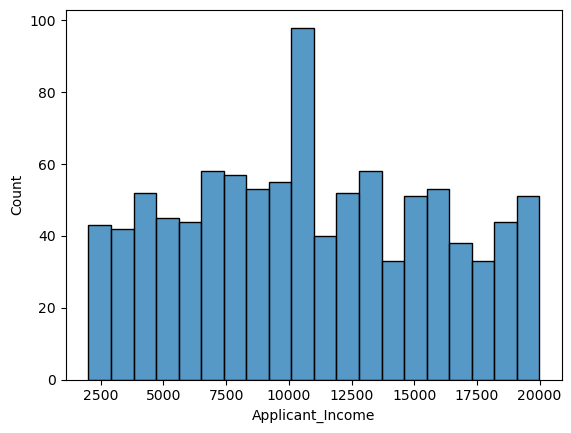

In [30]:
# Analyze Income

sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20

)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

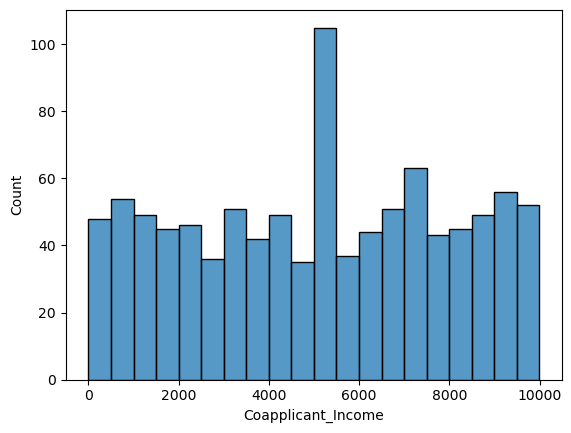

In [31]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20

)

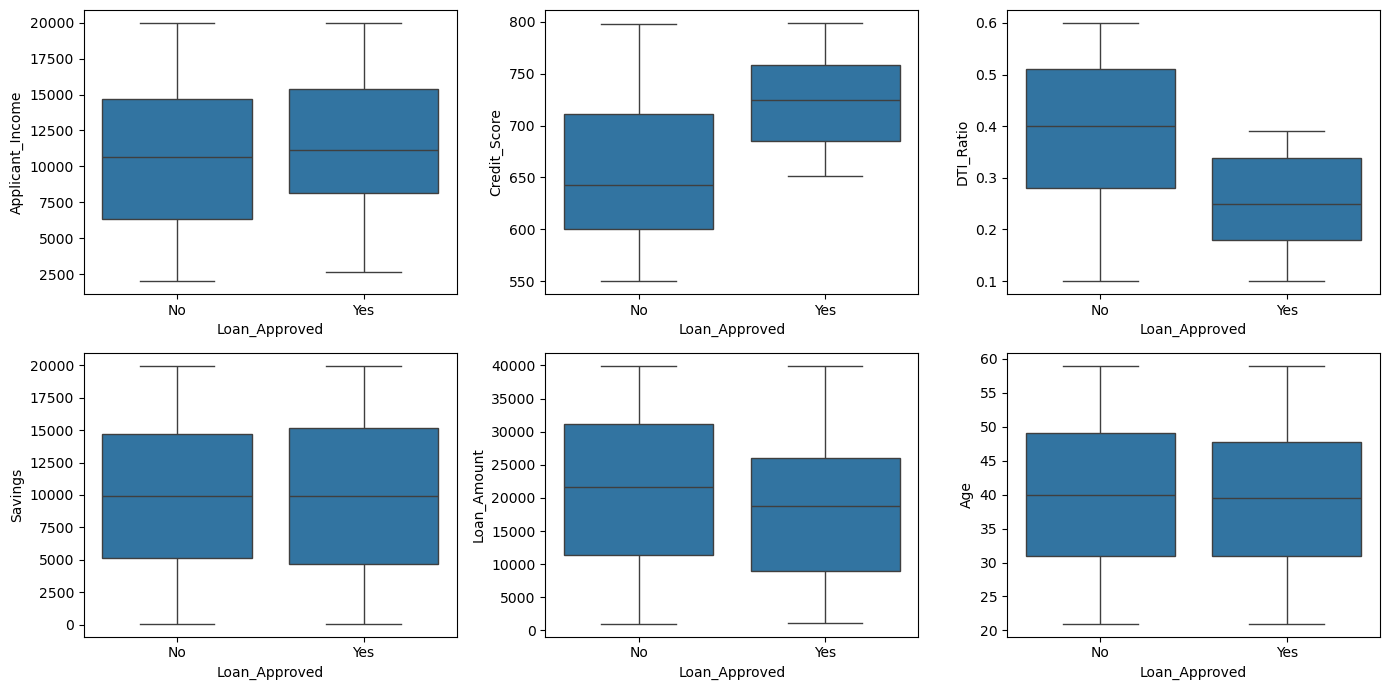

In [32]:
fig, axes = plt.subplots(2, 3 , figsize=(14, 7))
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[0,2],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Loan_Amount")
sns.boxplot(ax=axes[1,2],data=df,x="Loan_Approved",y="Age")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

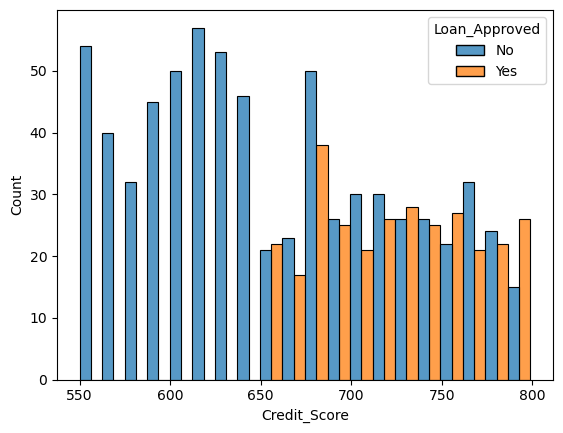

In [35]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue ="Loan_Approved",
    bins=20,
    multiple="dodge"
)

## Loan Approved Where Credit Score Is Higher Than 650

In [37]:
# Remove Applicant Id

df= df.drop(columns=["Applicant_ID"])

In [38]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## Encoding

In [ ]:
# LabelEncoder   => Ordinal Data
# OneHotEncoder  => Nominal Data

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [44]:
le= LabelEncoder()
df["Education_Level"]= le.fit_transform(df["Education_Level"])
df["Loan_Approved"]= le.fit_transform(df["Loan_Approved"])

df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [47]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category" ]

ohe= OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded= ohe.fit_transform(df[cols])


In [48]:
encoded

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(1000, 15))

In [50]:
ohe.get_feature_names_out(cols)

array(['Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed'],
      dtype=object)

In [51]:
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols) ,index=df.index)

In [52]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [53]:
# Data Is Now Encoded And Updated
df= pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [55]:
df.shape

(1000, 28)

# Corelation Heat Map


In [57]:
nums_cols= df.select_dtypes(include="number")
corr_matrix= nums_cols.corr()

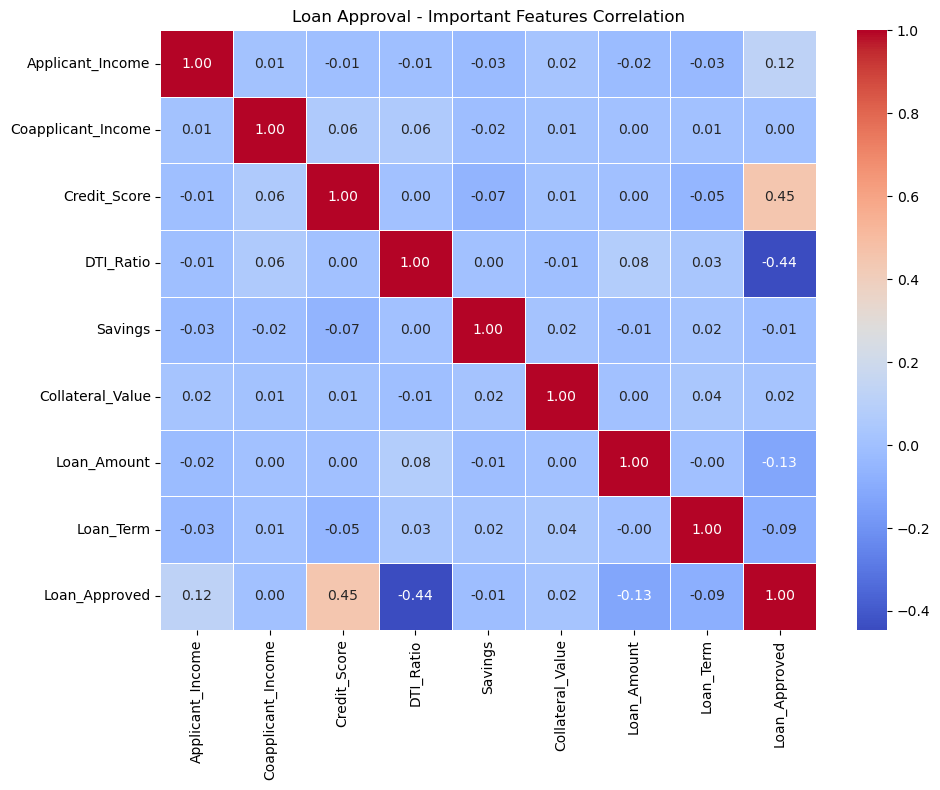

In [63]:
features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Credit_Score",
    "DTI_Ratio",
    "Savings",
    "Collateral_Value",
    "Loan_Amount",
    "Loan_Term",
    "Loan_Approved"
]

corr = df[features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Loan Approval - Important Features Correlation")
plt.tight_layout()
plt.show()

## Train Test Split

In [64]:
X= df.drop(columns=["Loan_Approved"])
y= df["Loan_Approved"]

In [68]:
X.shape

(1000, 27)

In [70]:
y.shape

(1000,)

In [72]:
X_train , X_test, y_train , y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [74]:
#Standard Scaling
scaler= StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

## Train & Evaluate Models

In [96]:
## Logistic Regression

log_model= LogisticRegression()
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [100]:
# Predicted
y_pred=log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")

print(f"Precision Score : {precision_score(y_test, y_pred)}")
print(f"Recall Score    : {recall_score(y_test, y_pred)}")
print(f"F1 Score        : {f1_score(y_test, y_pred)}")
print(f"Accuracy Score  : {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Logistic Regression Model
Precision Score : 0.7833333333333333
Recall Score    : 0.7704918032786885
F1 Score        : 0.7768595041322314
Accuracy Score  : 0.865
Confusion Matrix:
[[126  13]
 [ 14  47]]


In [102]:
## KNN Model

knn_model= KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [106]:

# Predicted
y_pred= knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")

print(f"Precision Score : {precision_score(y_test, y_pred)}")
print(f"Recall Score    : {recall_score(y_test, y_pred)}")
print(f"F1 Score        : {f1_score(y_test, y_pred)}")
print(f"Accuracy Score  : {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

KNN Model
Precision Score : 0.6274509803921569
Recall Score    : 0.5245901639344263
F1 Score        : 0.5714285714285714
Accuracy Score  : 0.76
Confusion Matrix:
[[120  19]
 [ 29  32]]


In [98]:
## Naive Bayes

nb_model= GaussianNB()
nb_model.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


In [99]:
# Predicted
y_pred= nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")

print(f"Precision Score : {precision_score(y_test, y_pred)}")
print(f"Recall Score    : {recall_score(y_test, y_pred)}")
print(f"F1 Score        : {f1_score(y_test, y_pred)}")
print(f"Accuracy Score  : {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Naive Bayes Model

Precision Score : 0.8035714285714286
Recall Score    : 0.7377049180327869
F1 Score        : 0.7692307692307693
Accuracy Score  : 0.865
Confusion Matrix:
[[128  11]
 [ 16  45]]


#### Best Model On The Basis Of These Is (Naive Bayes)

## Feature Engineering

In [110]:
df["DTI_Ratio_Sq"]= df["DTI_Ratio"]**2
df["Credit_Score_Sq"]= df["Credit_Score"]**2

# df["Application_Income_log"]= np.log1p(df["Applicant_Income"])

X= df.drop(columns=["Loan_Approved","DTI_Ratio", "Credit_Score"])

# Train Test Split
X_train , X_test, y_train , y_test= train_test_split(X,y, test_size=0.2, random_state=42)

#Standard Scaling
scaler= StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)




## After Feature Engineering

In [111]:
## Logistic Regression

log_model= LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Predicted
y_pred=log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")

print(f"Precision Score : {precision_score(y_test, y_pred)}")
print(f"Recall Score    : {recall_score(y_test, y_pred)}")
print(f"F1 Score        : {f1_score(y_test, y_pred)}")
print(f"Accuracy Score  : {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


Logistic Regression Model
Precision Score : 0.7846153846153846
Recall Score    : 0.8360655737704918
F1 Score        : 0.8095238095238095
Accuracy Score  : 0.88
Confusion Matrix:
[[125  14]
 [ 10  51]]


In [112]:
## Naive Bayes

nb_model= GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Predicted
y_pred= nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")

print(f"Precision Score : {precision_score(y_test, y_pred)}")
print(f"Recall Score    : {recall_score(y_test, y_pred)}")
print(f"F1 Score        : {f1_score(y_test, y_pred)}")
print(f"Accuracy Score  : {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


Naive Bayes Model
Precision Score : 0.8113207547169812
Recall Score    : 0.7049180327868853
F1 Score        : 0.7543859649122807
Accuracy Score  : 0.86
Confusion Matrix:
[[129  10]
 [ 18  43]]


In [113]:
## KNN Model

knn_model= KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)


# Predicted
y_pred= knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")

print(f"Precision Score : {precision_score(y_test, y_pred)}")
print(f"Recall Score    : {recall_score(y_test, y_pred)}")
print(f"F1 Score        : {f1_score(y_test, y_pred)}")
print(f"Accuracy Score  : {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


KNN Model
Precision Score : 0.6730769230769231
Recall Score    : 0.5737704918032787
F1 Score        : 0.6194690265486725
Accuracy Score  : 0.785
Confusion Matrix:
[[122  17]
 [ 26  35]]


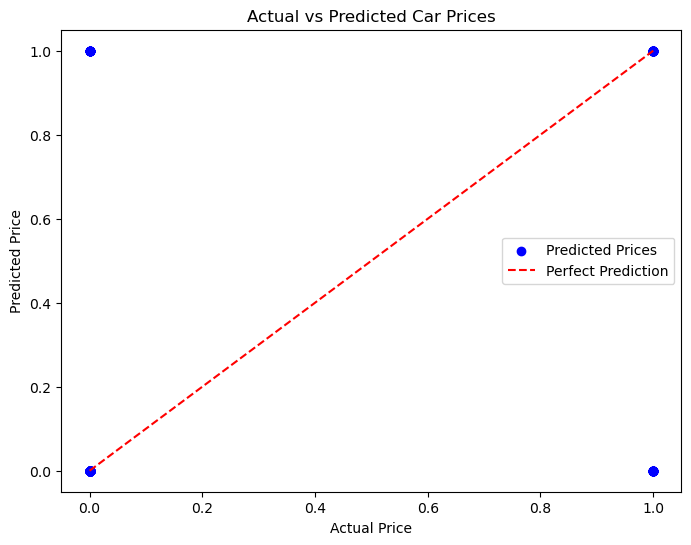